<a href="https://colab.research.google.com/github/christy5165/Denoising_Autoencoder.ipynb/blob/main/DCGAN-WK-8.B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Training DCGAN to generate squares...
Epoch [0/1000] | Loss G: 1.4058
Epoch [200/1000] | Loss G: 5.0822
Epoch [400/1000] | Loss G: 4.2276
Epoch [600/1000] | Loss G: 3.6608
Epoch [800/1000] | Loss G: 4.9209

Generated Shapes:


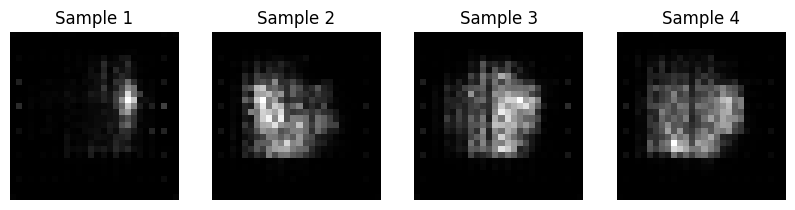

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
# 1. GENERATE SYNTHETIC "SQUARE" DATA
# ---------------------------------------------------------
def get_square_data(n=1000):
    # Create black images
    data = torch.zeros((n, 1, 28, 28))
    for i in range(n):
        # Pick a random top-left corner
        r = np.random.randint(2, 15)
        c = np.random.randint(2, 15)
        # Draw a 10x10 white square
        data[i, 0, r:r+10, c:c+10] = 1.0
    # Add light noise
    return data + torch.randn_like(data) * 0.05

# ---------------------------------------------------------
# 2. DEFINE DCGAN ARCHITECTURE
# ---------------------------------------------------------
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            # Input: 100 random numbers
            nn.ConvTranspose2d(100, 128, 7, 1, 0, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            # Upsample to 14x14
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            # Upsample to 28x28
            nn.ConvTranspose2d(64, 1, 4, 2, 1, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.main(x)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            # 28x28 -> 14x14
            nn.Conv2d(1, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # 14x14 -> 7x7
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            # Final Judge
            nn.Conv2d(128, 1, 7, 1, 0, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.main(x).view(-1, 1)

# Initialize
netG = Generator()
netD = Discriminator()
optG = optim.Adam(netG.parameters(), lr=0.0002, betas=(0.5, 0.999))
optD = optim.Adam(netD.parameters(), lr=0.0002, betas=(0.5, 0.999))
criterion = nn.BCELoss()

# ---------------------------------------------------------
# 3. TRAINING LOOP
# ---------------------------------------------------------
epochs = 1000
batch_size = 32

print("Training DCGAN to generate squares...")
for epoch in range(epochs):
    # --- Train Discriminator ---
    netD.zero_grad()
    real_imgs = get_square_data(batch_size)
    lossD_real = criterion(netD(real_imgs), torch.ones(batch_size, 1))

    noise = torch.randn(batch_size, 100, 1, 1)
    fake_imgs = netG(noise)
    lossD_fake = criterion(netD(fake_imgs.detach()), torch.zeros(batch_size, 1))

    (lossD_real + lossD_fake).backward()
    optD.step()

    # --- Train Generator ---
    netG.zero_grad()
    lossG = criterion(netD(fake_imgs), torch.ones(batch_size, 1))
    lossG.backward()
    optG.step()

    if epoch % 200 == 0:
        print(f"Epoch [{epoch}/{epochs}] | Loss G: {lossG.item():.4f}")

# ---------------------------------------------------------
# 4. PLOT RESULTS
# ---------------------------------------------------------
print("\nGenerated Shapes:")
with torch.no_grad():
    noise = torch.randn(4, 100, 1, 1)
    samples = netG(noise)

plt.figure(figsize=(10, 3))
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(samples[i].squeeze(), cmap='gray')
    plt.axis('off')
    plt.title(f"Sample {i+1}")
plt.show()